# Part 3 — CO₂ sweep

In [1]:
# Parser from parse_MODTRAN.py (provided on Canvas)
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path



def is_header_line(line: str) -> bool:
    return "RADIANCE(WATTS/CM2-STER" in line

def is_block_terminator(line: str) -> bool:
    return line.strip().startswith("iv")

float_re = re.compile(r"[-+]?(?:\d+\.\d*|\.\d+|\d+)(?:[eEdD][-+]?\d+)?")

def try_parse_data_line(line: str):
    nums = float_re.findall(line)
    if len(nums) == 12:
        return list(map(lambda x: float(x.replace("D","E").replace("d","e")), nums))
    return None


def read_file(spath):
    text = spath.read_text(errors="ignore").splitlines()
    rows = []
    in_block = False
    skip_next = 0
    for ln in text:
        if is_header_line(ln):
            in_block = True
            skip_next = 2  # the two column header lines immediately after the title
            continue
        if in_block and skip_next > 0:
            skip_next -= 1
            continue
        if in_block:
            if is_block_terminator(ln):
                in_block = False
                continue
            parsed = try_parse_data_line(ln)
            if parsed is not None:
                rows.append(parsed)
    if not rows:
        raise RuntimeError("No radiance rows were detected.")
    cols = [
        "wn_cm1", "wav_um",
        "path_therm_cm1","path_therm_um",
        "surf_emis_cm1","surf_emis_um",
        "surf_refl_cm1","surf_refl_um",
        "total_cm1","total_um",
        "integral_cm1","trans"
    ]
    df = pd.DataFrame(rows, columns=cols)
    df.sort_values("wn_cm1", inplace=True)
    df.drop_duplicates(subset=["wn_cm1"], keep="last", inplace=True)
    df.sort_values("wav_um", inplace=True)
    return df

In [2]:
def BlackBody(w, T):
    # w: wavelength in meters, T: temperature in Kelvin
    # Returns spectral radiance in W m^-2 sr^-1 m^-1
    h = 6.62606957e-34  # joule·s
    c = 2.99792458e8  # Speed of light in m/s
    k = 1.38e-23  # Boltzmann constant in m^2 kg / s^2 / K
    return (2*h*c**2/w**5)*(1/(np.exp((h*c)/(w*k*T)) - 1))

In [3]:
def to_nm_units(df):
    # Returns (wavelength in nm, total radiance in W m^-2 sr^-1 nm^-1)
    # df has wav_um in µm and total_um in W cm^-2 sr^-1 µm^-1
    wl_nm = df["wav_um"].values*1e3  # µm -> nm
    rad = df["total_um"].values*1e4*1e-3  # cm^-2 -> m^-2, µm^-1 -> nm^-1
    return wl_nm, rad

In [4]:
def read_flux(spath):
    # Upward IR flux in W m^-2: pi * integrated radiance (W cm^-2 sr^-1 in the raw output) * 1e4
    m = re.search(r"INTEGRATED RADIANCE =\s*([\d.E+-]+)", spath.read_text(errors="ignore"))
    return float(m.group(1))*np.pi*1e4

In [5]:
# MODTRAN runs: same setup as Part 2, looking down from 100 km, only CO2 changed
co2_values = [0, 1, 10, 50, 100, 200, 300, 400, 425, 500, 600, 700, 800]  # ppm
co2_spectra = {c: read_file(Path(f"data/co2_sweep/CO2_{c}.txt")) for c in co2_values}

co2_table = pd.DataFrame({
    "CO2 (ppm)": co2_values,
    "IR out (W m^-2)": [read_flux(Path(f"data/co2_sweep/CO2_{c}.txt")) for c in co2_values],
})
co2_table["Change from 0 ppm (W m^-2)"] = co2_table["IR out (W m^-2)"] - co2_table["IR out (W m^-2)"].iloc[0]
co2_table.round(2)

,CO2 (ppm),IR out (W m^-2),Change from 0 ppm (W m^-2)
0,0,318.24,0.00
1,1,313.72,-4.52
2,10,305.87,-12.38
3,50,298.55,-19.70
4,100,295.50,-22.75
5,200,292.51,-25.73
6,300,290.79,-27.46
7,400,289.53,-28.71
8,425,289.28,-28.97
9,500,288.56,-29.69


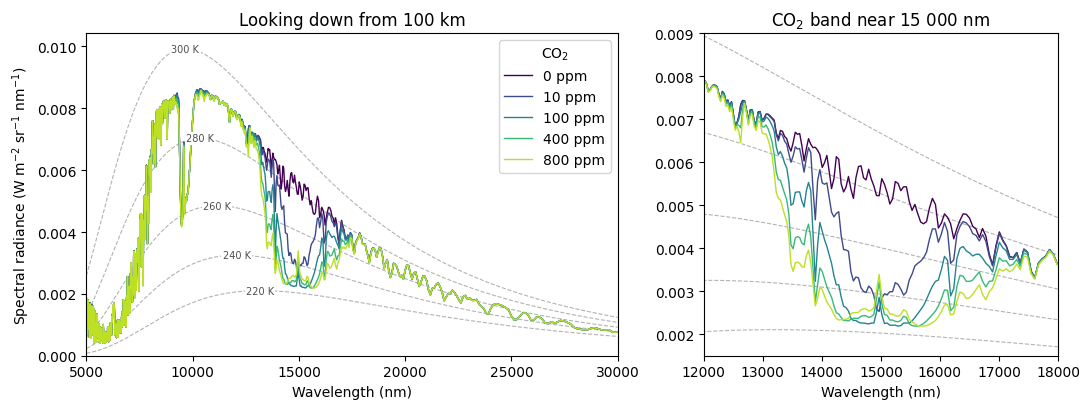

In [6]:
bb_temps = [220, 240, 260, 280, 300]  # K
wl_bb = np.linspace(5000, 30000, 500)  # nm
co2_selected = [0, 10, 100, 400, 800]  # ppm
colors = plt.cm.viridis(np.linspace(0, 0.9, len(co2_selected)))

fig, (ax_full, ax_zoom) = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={"width_ratios": [3, 2]})

for ax in (ax_full, ax_zoom):
    for T in bb_temps:
        bb = BlackBody(wl_bb*1e-9, T)*1e-9  # per m -> per nm
        ax.plot(wl_bb, bb, color="0.7", lw=0.8, ls="--")
    for c, col in zip(co2_selected, colors):
        wl, rad = to_nm_units(co2_spectra[c])
        ax.plot(wl, rad, lw=1.0, color=col, label=f"{c} ppm")
    ax.set_xlabel("Wavelength (nm)")

for T in bb_temps:
    wl_peak = 2.898e6/T  # nm
    ax_full.text(wl_peak, BlackBody(wl_peak*1e-9, T)*1e-9, f"{T} K", fontsize=7, color="0.3",
                 ha="center", va="center", bbox=dict(facecolor="white", edgecolor="none", pad=1))

ax_full.set_xlim(5000, 30000)
ax_full.set_ylim(bottom=0)
ax_full.set_ylabel("Spectral radiance (W m$^{-2}$ sr$^{-1}$ nm$^{-1}$)")
ax_full.set_title("Looking down from 100 km")
ax_full.legend(title="CO$_2$")

# zoom on the CO2 band near 15 µm
ax_zoom.set_xlim(12000, 18000)
ax_zoom.set_ylim(0.0015, 0.009)
ax_zoom.set_title("CO$_2$ band near 15 000 nm")

plt.tight_layout()
plt.savefig("figures/part3_co2_spectra.png", dpi=200)
plt.show()

Fit for CO2 >= 50 ppm: F = 315.48 + -4.33 ln(CO2)
Change per doubling of CO2: -3.00 W m^-2


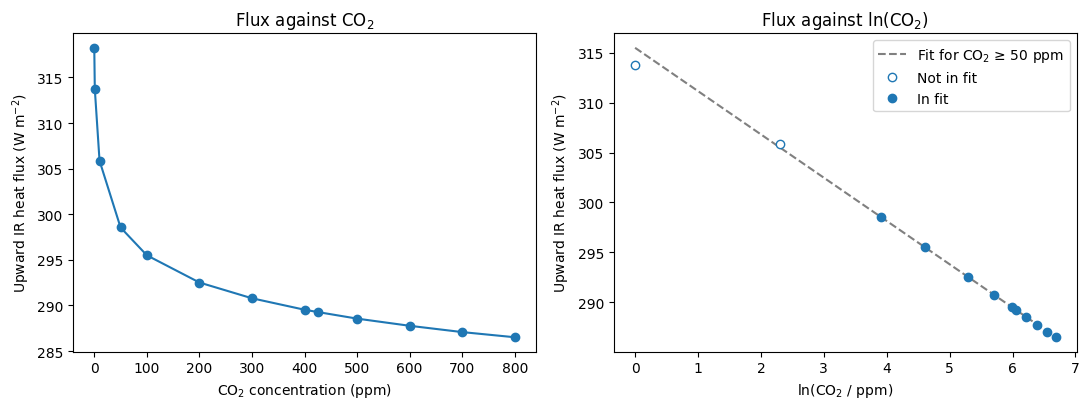

In [7]:
co2 = co2_table["CO2 (ppm)"].values
flux = co2_table["IR out (W m^-2)"].values

# straight-line fit of flux against ln(CO2) over the range that looks logarithmic
fit_min = 50  # ppm
in_fit = co2 >= fit_min
slope, intercept = np.polyfit(np.log(co2[in_fit]), flux[in_fit], 1)
print(f"Fit for CO2 >= {fit_min} ppm: F = {intercept:.2f} + {slope:.2f} ln(CO2)")
print(f"Change per doubling of CO2: {slope*np.log(2):.2f} W m^-2")

fig, (ax_lin, ax_log) = plt.subplots(1, 2, figsize=(11, 4.2))

ax_lin.plot(co2, flux, "o-")
ax_lin.set_xlabel("CO$_2$ concentration (ppm)")
ax_lin.set_ylabel("Upward IR heat flux (W m$^{-2}$)")
ax_lin.set_title("Flux against CO$_2$")

# ln(0) is undefined, so the 0 ppm run is left out here
pos = co2 > 0
ln_fit = np.linspace(np.log(co2[pos].min()), np.log(co2.max()), 50)
ax_log.plot(ln_fit, intercept + slope*ln_fit, color="0.5", ls="--", label=f"Fit for CO$_2$ ≥ {fit_min} ppm")
ax_log.plot(np.log(co2[pos & ~in_fit]), flux[pos & ~in_fit], "o", mfc="white", label="Not in fit")
ax_log.plot(np.log(co2[in_fit]), flux[in_fit], "o", color="C0", label="In fit")
ax_log.set_xlabel("ln(CO$_2$ / ppm)")
ax_log.set_ylabel("Upward IR heat flux (W m$^{-2}$)")
ax_log.set_title("Flux against ln(CO$_2$)")
ax_log.legend()

plt.tight_layout()
plt.savefig("figures/part3_co2_flux.png", dpi=200)
plt.show()